<a href="https://colab.research.google.com/github/ylperdomo/Calculo-Numerico/blob/Atividade-CN/Atividade3_CN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Atividade prática III

In [7]:
#Importa as bibliotecas necessarias
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

#Define um tamanho padrão para os gráficos
plt.rcParams["figure.figsize"] = (8, 4.5)

#Ativa a grade por padrão
plt.rcParams["axes.grid"] = True

#Define a tolerância
TOL = 1e-6

#Define o número máximo de iterações
MAX_ITER = 100

#Define um limite menor para detectar divisoes de valores quase nulos
LIMITE_ZERO = 1e-14

## 1. Funções investigadas

As quatro funções e suas derivadas são:

$$f_1(x)=x^2-2, \qquad f_1'(x)=2x,$$
$$f_2(x)=x^3-x-2, \qquad f_2'(x)=3x^2-1,$$
$$f_3(x)=e^{-x}-x, \qquad f_3'(x)=-e^{-x}-1,$$
$$f_4(x)=x^3-2x+2, \qquad f_4'(x)=3x^2-2.$$

In [1]:
#Define f1(x) = x² - 2
def f1(x):
    #Retorna o valor de f1 no ponto x
    return x**2 - 2

#Define a derivada de f1
def df1(x):
    # Retorna f1'(x) = 2x
    return 2*x

#Define f2(x) = x³ - x - 2
def f2(x):
    #Retorna o valor de f2 no ponto x
    return x**3 - x - 2

#Define a derivada de f2
def df2(x):
    #Retorna f2'(x) = 3x² - 1
    return 3*x**2 - 1

#Define f3(x) = exp(-x) - x
def f3(x):
    #Retorna o valor de f3 no ponto x
    return math.exp(-x) - x

#Define a derivada de f3
def df3(x):
    #Retorna f3'(x) = -exp(-x) - 1
    return -math.exp(-x) - 1

#Define f4(x) = x³ - 2x + 2
def f4(x):
    #Retorna o valor de f4 no ponto x
    return x**3 - 2*x + 2

#Define a derivada de f4
def df4(x):
    #Retorna f4'(x) = 3x² - 2
    return 3*x**2 - 2

## 2. Método da bisseção

In [8]:
#Define uma função geral para o método da bisseção
def bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER):
    #Converte o extremo esquerdo para ponto flutuante
    a = float(a)
    #Converte o extremo direito para ponto flutuante
    b = float(b)
    #Calcula a função no extremo esquerdo apenas uma vez
    fa = f(a)
    #Calcula a função no extremo direito apenas uma vez
    fb = f(b)
    #Cria a lista que armazenará os pontos médios calculados
    aproximacoes = []
    #Cria a lista usada nas tabelas e na animação
    historico = []

    #Verifica se algum valor inicial não é um número finito
    if not all(math.isfinite(v) for v in [a, b, fa, fb]):
        #Retorna uma falha sem iniciar as iterações
        return {"raiz": math.nan, "iteracoes": 0, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: valor inicial não finito"}

    #Verifica se o extremo esquerdo já é uma raiz suficientemente boa
    if abs(fa) <= tol:
        #Retorna imediatamente o extremo esquerdo
        return {"raiz": a, "iteracoes": 0, "aproximacoes": [a], "historico": historico, "convergiu": True, "mensagem": "convergiu: a já satisfaz a tolerância"}

    #Verifica se o extremo direito já é uma raiz suficientemente boa
    if abs(fb) <= tol:
        #Retorna imediatamente o extremo direito
        return {"raiz": b, "iteracoes": 0, "aproximacoes": [b], "historico": historico, "convergiu": True, "mensagem": "convergiu: b já satisfaz a tolerância"}

    #Verifica se o intervalo possui mudança de sinal
    if fa * fb > 0:
        #Informa que a hipótese básica da bisseção não foi satisfeita
        return {"raiz": math.nan, "iteracoes": 0, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: f(a) e f(b) têm o mesmo sinal"}

    #Repete o processo no máximo max_iter vezes
    for k in range(1, max_iter + 1):
        #Calcula o ponto médio do intervalo atual
        c = (a + b) / 2
        #Calcula a função no ponto médio
        fc = f(c)
        #Guarda a aproximação desta iteração
        aproximacoes.append(c)
        #Registra todos os dados necessários para analisar o passo
        historico.append({"k": k, "a": a, "b": b, "c": c, "f(c)": fc, "residuo": abs(fc), "largura": abs(b-a)})

        #Testa se o resíduo do ponto médio atingiu a tolerância
        if abs(fc) <= tol:
            #Retorna o ponto médio como raiz aproximada
            return {"raiz": c, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": True, "mensagem": "convergiu pelo resíduo"}

        #Verifica se a raiz continua entre a e c
        if fa * fc < 0:
            #Substitui o extremo direito pelo ponto médio
            b = c
            #Atualiza o valor da função no extremo direito
            fb = fc
        #Caso contrário, a raiz continua entre c e b
        else:
            #Substitui o extremo esquerdo pelo ponto médio
            a = c
            #Atualiza o valor da função no extremo esquerdo
            fa = fc

        #Detecta se o intervalo ficou numericamente muito pequeno
        if abs(b - a) <= tol:
            #Calcula uma última aproximação no centro do intervalo reduzido
            c_final = (a + b) / 2
            #Calcula o resíduo dessa aproximação final
            residuo_final = abs(f(c_final))
            #Verifica se a última aproximação também satisfaz o critério de resíduo
            if residuo_final <= tol:
                #Guarda a aproximação final calculada após a redução
                aproximacoes.append(c_final)
                #Retorna sucesso porque passo e resíduo são pequenos
                return {"raiz": c_final, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": True, "mensagem": "convergiu pelo resíduo após intervalo pequeno"}

    #Usa a última aproximação se o limite de iterações for atingido
    raiz_final = aproximacoes[-1] if aproximacoes else math.nan
    #Retorna uma indicação explícita de não convergência
    return {"raiz": raiz_final, "iteracoes": max_iter, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: máximo de iterações atingido"}

## 3. Método de Newton

$$x_{k+1}=x_k-\frac{f(x_k)}{f'(x_k)}.$$

In [9]:
#Define uma função geral para o método de Newton
def newton(f, df, x0, tol=TOL, max_iter=MAX_ITER, deriv_tol=LIMITE_ZERO):
    #Converte a aproximação inicial para ponto flutuante
    x = float(x0)
    #Guarda x0 como a primeira aproximação conhecida
    aproximacoes = [x]
    #Cria o histórico detalhado das atualizações
    historico = []

    #Repete as atualizações no máximo max_iter vezes
    for k in range(1, max_iter + 1):
        #Calcula o valor da função no ponto atual
        fx = f(x)
        #Calcula o valor da derivada no ponto atual
        dfx = df(x)

        #Interrompe se função ou derivada produzirem valor não finito
        if not all(math.isfinite(v) for v in [x, fx, dfx]):
            #Retorna a última aproximação válida com uma mensagem de falha
            return {"raiz": x, "iteracoes": k-1, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: valor não finito"}

        #Verifica se a aproximação atual já satisfaz o critério de resíduo
        if abs(fx) <= tol:
            #Retorna sem calcular uma atualização desnecessária
            return {"raiz": x, "iteracoes": k-1, "aproximacoes": aproximacoes, "historico": historico, "convergiu": True, "mensagem": "convergiu pelo resíduo"}

        #Verifica se a derivada é nula ou pequena demais para uma divisão segura
        if abs(dfx) <= deriv_tol:
            #Retorna uma falha para evitar um passo indefinido ou exagerado
            return {"raiz": x, "iteracoes": k-1, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: derivada nula ou muito pequena"}

        #Aplica a fórmula de Newton para obter a nova aproximação
        x_novo = x - fx / dfx
        #Calcula a função na nova aproximação
        fx_novo = f(x_novo)
        #Calcula o tamanho do passo realizado
        passo = abs(x_novo - x)
        #Registra os valores usados na reta tangente desta iteração
        historico.append({"k": k, "x": x, "f(x)": fx, "df(x)": dfx, "x_novo": x_novo, "residuo_novo": abs(fx_novo), "passo": passo})
        #Guarda a nova aproximação na lista pedida no enunciado
        aproximacoes.append(x_novo)

        #Interrompe se a atualização tiver produzido um valor não finito
        if not all(math.isfinite(v) for v in [x_novo, fx_novo]):
            #Retorna falha por divergência numérica
            return {"raiz": x, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: valor não finito após a atualização"}

        #Verifica se o resíduo da nova aproximação atingiu a tolerância
        if abs(fx_novo) <= tol:
            #Retorna sucesso e a nova aproximação
            return {"raiz": x_novo, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": True, "mensagem": "convergiu pelo resíduo"}

        #Verifica se o método parou de alterar a aproximação
        if passo <= tol:
            #Retorna falha porque um passo pequeno com resíduo alto indica estagnação
            return {"raiz": x_novo, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: passo pequeno, mas resíduo ainda alto"}

        #Atualiza x para iniciar a próxima iteração
        x = x_novo

    #Retorna a aproximação final se o máximo de iterações for alcançado
    return {"raiz": x, "iteracoes": max_iter, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: máximo de iterações atingido"}

## 4. Método da secante
$$x_{k+1}=x_k-f(x_k)\frac{x_k-x_{k-1}}{f(x_k)-f(x_{k-1})}.$$

In [12]:
#Define uma função geral para o método da secante
def secante(f, x0, x1, tol=TOL, max_iter=MAX_ITER, denom_tol=LIMITE_ZERO):
    #Converte a primeira aproximação inicial para ponto flutuante
    x_anterior = float(x0)
    #Converte a segunda aproximação inicial para ponto flutuante
    x_atual = float(x1)
    #Guarda as duas aproximações iniciais
    aproximacoes = [x_anterior, x_atual]
    #Cria o histórico detalhado das retas secantes
    historico = []

    #Repete as atualizações no máximo max_iter vezes
    for k in range(1, max_iter + 1):
        #Calcula a função na aproximação anterior
        f_anterior = f(x_anterior)
        #Calcula a função na aproximação atual
        f_atual = f(x_atual)

        #Interrompe se algum valor usado não for finito
        if not all(math.isfinite(v) for v in [x_anterior, x_atual, f_anterior, f_atual]):
            #Retorna a aproximação atual e informa a falha
            return {"raiz": x_atual, "iteracoes": k-1, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: valor não finito"}

        #Verifica se a aproximação atual já satisfaz a tolerância
        if abs(f_atual) <= tol:
            #Retorna sucesso sem calcular outra atualização
            return {"raiz": x_atual, "iteracoes": k-1, "aproximacoes": aproximacoes, "historico": historico, "convergiu": True, "mensagem": "convergiu pelo resíduo"}

        #Calcula o denominador presente na fórmula da secante
        denominador = f_atual - f_anterior
        #Verifica se o denominador é nulo ou muito pequeno
        if abs(denominador) <= denom_tol:
            #Retorna uma falha para evitar divisão instável
            return {"raiz": x_atual, "iteracoes": k-1, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: denominador nulo ou muito pequeno"}

        #Aplica a fórmula da secante para obter a nova aproximação
        x_novo = x_atual - f_atual * (x_atual - x_anterior) / denominador
        #Calcula a função na nova aproximação
        f_novo = f(x_novo)
        #Calcula o tamanho do passo realizado
        passo = abs(x_novo - x_atual)
        #Registra os dois pontos e a interseção da secante com o eixo x
        historico.append({"k": k, "x_anterior": x_anterior, "x_atual": x_atual, "f_anterior": f_anterior, "f_atual": f_atual, "x_novo": x_novo, "residuo_novo": abs(f_novo), "passo": passo})
        #Acrescenta a nova aproximação à lista completa
        aproximacoes.append(x_novo)

        #Interrompe se o novo valor não for finito
        if not all(math.isfinite(v) for v in [x_novo, f_novo]):
            #Retorna falha por divergência numérica
            return {"raiz": x_atual, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: valor não finito após a atualização"}

        #Verifica se a nova aproximação atingiu o resíduo desejado
        if abs(f_novo) <= tol:
            #Retorna sucesso com a nova aproximação
            return {"raiz": x_novo, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": True, "mensagem": "convergiu pelo resíduo"}

        #Verifica se houve um passo pequeno sem resíduo suficientemente pequeno
        if passo <= tol:
            #Retorna uma indicação de estagnação
            return {"raiz": x_novo, "iteracoes": k, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: passo pequeno, mas resíduo ainda alto"}

        #Desloca a aproximação atual para a posição anterior
        x_anterior = x_atual
        #Coloca a nova aproximação na posição atual
        x_atual = x_novo

    #Eetorna a aproximação final se o máximo de iterações for atingido
    return {"raiz": x_atual, "iteracoes": max_iter, "aproximacoes": aproximacoes, "historico": historico, "convergiu": False, "mensagem": "falha: máximo de iterações atingido"}

## 5. Aplicação às quatro funções e tabela de resultados

In [13]:
#Reúne as funções, derivadas e valores iniciais em uma estrutura editável
problemas = [
    #Dados correspondentes à função f1
    {"nome": "f1(x) = x² - 2", "f": f1, "df": df1, "intervalo": (1, 2), "x0_newton": 1.5, "pontos_secante": (1, 2)},
    #Dados correspondentes à função f2
    {"nome": "f2(x) = x³ - x - 2", "f": f2, "df": df2, "intervalo": (1, 2), "x0_newton": 1.5, "pontos_secante": (1, 2)},
    #Dados correspondentes à função f3
    {"nome": "f3(x) = exp(-x) - x", "f": f3, "df": df3, "intervalo": (0, 1), "x0_newton": 0.5, "pontos_secante": (0, 1)},
    #Dados correspondentes à função f4
    {"nome": "f4(x) = x³ - 2x + 2", "f": f4, "df": df4, "intervalo": (-2, -1), "x0_newton": -2, "pontos_secante": (-2, -1)}
]

#Cria a lista que receberá uma linha para cada combinação de função e método
linhas_resultados = []

#Cria um dicionário para guardar os resultados completos e reutilizá-los nas animações
resultados_completos = {}

#Percorre cada problema definido na lista
for problema in problemas:
    #Obtém a função do problema atual
    f = problema["f"]
    #Obtém a derivada do problema atual
    df = problema["df"]
    #Separa os extremos usados na bisseção
    a, b = problema["intervalo"]
    #Separa os pontos iniciais usados na secante
    x0_s, x1_s = problema["pontos_secante"]

    #Executa o método da bisseção
    resultado_b = bissecao(f, a, b, tol=TOL, max_iter=MAX_ITER)
    #Executa o método de Newton
    resultado_n = newton(f, df, problema["x0_newton"], tol=TOL, max_iter=MAX_ITER)
    #Executa o método da secante
    resultado_s = secante(f, x0_s, x1_s, tol=TOL, max_iter=MAX_ITER)

    #Guarda os três resultados completos associados ao nome da função
    resultados_completos[problema["nome"]] = {"Bisseção": resultado_b, "Newton": resultado_n, "Secante": resultado_s}

    #Percorre os três resultados para montar as linhas da tabela final
    for metodo, resultado, iniciais in [
        #Informa o intervalo usado pela bisseção
        ("Bisseção", resultado_b, f"[{a}, {b}]"),
        #Informa a estimativa inicial usada por Newton
        ("Newton", resultado_n, f"x0 = {problema['x0_newton']}"),
        #Informa os dois pontos usados pela secante
        ("Secante", resultado_s, f"({x0_s}, {x1_s})")
    ]:
        #Obtém a raiz aproximada devolvida pelo método
        raiz = resultado["raiz"]
        #Calcula o resíduo final apenas quando a raiz é finita
        residuo = abs(f(raiz)) if math.isfinite(raiz) else math.nan
        #Acrescenta uma linha
        linhas_resultados.append({
            #Registra a função investigada
            "Função": problema["nome"],
            #Registra o método numérico utilizado
            "Método": metodo,
            #Registra os valores iniciais utilizados
            "Valores iniciais": iniciais,
            #Registra a raiz aproximada
            "Raiz aproximada": raiz,
            #Registra o módulo do valor final da função
            "|f(x)| final": residuo,
            #Registra o número de atualizações realizadas
            "Iterações": resultado["iteracoes"],
            #Registra sucesso ou falha
            "Convergiu": resultado["convergiu"],
            #Registra a explicação produzida pelo método
            "Resultado": resultado["mensagem"]
        })

#Converte a lista de linhas em uma tabela do pandas
tabela_resultados = pd.DataFrame(linhas_resultados)

#Cria uma cópia para melhorar a apresentação numérica na tela
tabela_exibicao = tabela_resultados.copy()

#Formata as raízes com dez casas decimais
tabela_exibicao["Raiz aproximada"] = tabela_exibicao["Raiz aproximada"].map(lambda valor: f"{valor:.10f}" if math.isfinite(valor) else "—")

#Formata os resíduos em notação científica
tabela_exibicao["|f(x)| final"] = tabela_exibicao["|f(x)| final"].map(lambda valor: f"{valor:.3e}" if math.isfinite(valor) else "—")

#Exibe a tabela completa solicitada na atividade
tabela_exibicao

,Função,Método,Valores iniciais,Raiz aproximada,|f(x)| final,Iterações,Convergiu,Resultado
0,f1(x) = x² - 2,Bisseção,"[1, 2]",1.4142136574,2.687e-07,20,True,convergiu pelo resíduo após intervalo pequeno
1,f1(x) = x² - 2,Newton,x0 = 1.5,1.4142135624,4.511e-12,3,True,convergiu pelo resíduo
2,f1(x) = x² - 2,Secante,"(1, 2)",1.4142135621,8.931e-10,5,True,convergiu pelo resíduo
3,f2(x) = x³ - x - 2,Bisseção,"[1, 2]",1.5213797092,1.450e-08,21,True,convergiu pelo resíduo após intervalo pequeno
4,f2(x) = x³ - x - 2,Newton,x0 = 1.5,1.5213798060,5.894e-07,2,True,convergiu pelo resíduo
5,f2(x) = x³ - x - 2,Secante,"(1, 2)",1.5213797080,7.015e-09,6,True,convergiu pelo resíduo
6,f3(x) = exp(-x) - x,Bisseção,"[0, 1]",0.5671434402,2.348e-07,20,True,convergiu pelo resíduo
7,f3(x) = exp(-x) - x,Newton,x0 = 0.5,0.5671431650,1.965e-07,2,True,convergiu pelo resíduo
8,f3(x) = exp(-x) - x,Secante,"(0, 1)",0.5671433066,2.538e-08,4,True,convergiu pelo resíduo
9,f4(x) = x³ - 2x + 2,Bisseção,"[-2, -1]",-1.7692923546,2.551e-09,20,True,convergiu pelo resíduo após intervalo pequeno


In [14]:
#Salva a tabela para facilitar sua inclusão no dashboard do Mathcha
tabela_resultados.to_csv("tabela_resultados_atividade_3.csv", index=False)

#Mostra uma confirmação simples após a gravação do arquivo
print("Tabela salva como tabela_resultados_atividade_3.csv")

Tabela salva como tabela_resultados_atividade_3.csv


## 6. Animações gráficas

In [15]:
#Calcula limites verticais apropriados para uma função em um intervalo
def limites_y(f, xlim):
    #Cria pontos igualmente espaçados no intervalo horizontal
    xs = np.linspace(xlim[0], xlim[1], 500)
    #Avalia a função em cada um desses pontos
    ys = np.array([f(float(x)) for x in xs])
    #Encontra o menor valor vertical
    y_min = float(np.min(ys))
    #Encontra o maior valor vertical
    y_max = float(np.max(ys))
    #Calcula uma margem proporcional à amplitude do gráfico
    margem = 0.15 * max(y_max - y_min, 1.0)
    #Retorna limites com espaço extra para os elementos gráficos
    return y_min - margem, y_max + margem

#Cria e salva uma animação para o método da bisseção
def animar_bissecao(f, resultado, xlim, nome_arquivo):
    #Recupera o histórico dos intervalos e pontos médios
    historico = resultado["historico"]
    #Cria os pontos horizontais usados para desenhar a função
    xs = np.linspace(xlim[0], xlim[1], 500)
    #Calcula os valores da função nesses pontos
    ys = np.array([f(float(x)) for x in xs])
    #Calcula limites verticais constantes para evitar que o gráfico pule
    ylim = limites_y(f, xlim)
    #Cria a figura e o eixo da animação
    fig, ax = plt.subplots(figsize=(8, 4.5))

    #Define o que será desenhado em cada quadro
    def atualizar(indice):
        #Limpa o quadro anterior
        ax.clear()
        #Obtém os dados da iteração correspondente ao quadro
        passo = historico[indice]
        #Desenha a curva da função
        ax.plot(xs, ys, color="royalblue", linewidth=2, label="f(x)")
        #Desenha o eixo horizontal y = 0
        ax.axhline(0, color="black", linewidth=0.9)
        #Destaca o intervalo que contém a raiz
        ax.axvspan(passo["a"], passo["b"], color="gold", alpha=0.28, label="intervalo atual")
        #Marca o extremo esquerdo do intervalo
        ax.axvline(passo["a"], color="darkorange", linestyle="--")
        #Marca o extremo direito do intervalo
        ax.axvline(passo["b"], color="darkorange", linestyle="--")
        #Marca o ponto médio sobre a curva
        ax.scatter([passo["c"]], [passo["f(c)"]], color="crimson", s=55, zorder=4, label="ponto médio")
        #Liga o ponto médio ao eixo horizontal
        ax.vlines(passo["c"], 0, passo["f(c)"], color="crimson", linestyle=":")
        #Define os limites horizontais
        ax.set_xlim(*xlim)
        #Define os limites verticais
        ax.set_ylim(*ylim)
        #Identifica o eixo horizontal
        ax.set_xlabel("x")
        #Identifica o eixo vertical
        ax.set_ylabel("f(x)")
        #Mostra iteração, aproximação e resíduo no título
        ax.set_title(f"Bisseção — iteração {passo['k']} | x = {passo['c']:.8f} | |f(x)| = {passo['residuo']:.2e}")
        #Exibe a legenda dos elementos
        ax.legend(loc="best")
        #Reativa a grade após limpar o eixo
        ax.grid(True)

    #Cria a animação com um quadro por passo do histórico
    animacao = FuncAnimation(fig, atualizar, frames=len(historico), interval=700, repeat=True)
    #Salva o resultado em GIF usando o Pillow
    animacao.save(nome_arquivo, writer=PillowWriter(fps=2))
    #Fecha a figura para evitar uma cópia
    plt.close(fig)
    #Retorna o nome do arquivo criado
    return nome_arquivo

In [16]:
#Cria e salva uma animação para o método de Newton
def animar_newton(f, resultado, xlim, nome_arquivo):
    #Recupera o histórico das retas tangentes
    historico = resultado["historico"]
    #Cria os pontos horizontais usados no gráfico
    xs = np.linspace(xlim[0], xlim[1], 500)
    #Avalia a função ao longo do intervalo
    ys = np.array([f(float(x)) for x in xs])
    #Calcula limites verticais constantes
    ylim = limites_y(f, xlim)
    #Cria a figura e o eixo da animação
    fig, ax = plt.subplots(figsize=(8, 4.5))

    #Define o desenho de cada quadro
    def atualizar(indice):
        #Limpa o conteúdo do quadro anterior
        ax.clear()
        #Obtém os dados da iteração atual
        passo = historico[indice]
        #Calcula a reta tangente usada por Newton
        tangente = passo["f(x)"] + passo["df(x)"] * (xs - passo["x"])
        #Desenha a curva da função
        ax.plot(xs, ys, color="royalblue", linewidth=2, label="f(x)")
        #Desenha o eixo horizontal y = 0
        ax.axhline(0, color="black", linewidth=0.9)
        #Desenha a reta tangente da iteração
        ax.plot(xs, tangente, color="darkorange", linestyle="--", label="reta tangente")
        #Marca o ponto de tangência
        ax.scatter([passo["x"]], [passo["f(x)"]], color="crimson", s=55, zorder=4, label="(xₖ, f(xₖ))")
        #Marca a nova aproximação no eixo x
        ax.scatter([passo["x_novo"]], [0], color="green", marker="x", s=80, zorder=5, label="xₖ₊₁")
        #Desenha as aproximações já produzidas sobre o eixo horizontal
        ax.scatter(resultado["aproximacoes"][:indice+2], np.zeros(indice+2), color="purple", s=22, alpha=0.6)
        #Define os limites horizontais
        ax.set_xlim(*xlim)
        #Define os limites verticais
        ax.set_ylim(*ylim)
        #Identifica o eixo horizontal
        ax.set_xlabel("x")
        #Identifica o eixo vertical
        ax.set_ylabel("f(x)")
        #Exibe os dados numéricos da iteração no título
        ax.set_title(f"Newton — iteração {passo['k']} | x = {passo['x_novo']:.8f} | |f(x)| = {passo['residuo_novo']:.2e}")
        #Exibe a legenda
        ax.legend(loc="best")
        #Reativa a grade
        ax.grid(True)

    #Cria a animação com todos os passos registrados
    animacao = FuncAnimation(fig, atualizar, frames=len(historico), interval=900, repeat=True)
    #Salva a animação no arquivo informado
    animacao.save(nome_arquivo, writer=PillowWriter(fps=1))
    #Fecha a figura
    plt.close(fig)
    #Retorna o nome do GIF criado
    return nome_arquivo

In [17]:
#Cria e salva uma animação para o método da secante
def animar_secante(f, resultado, xlim, nome_arquivo):
    #Recupera o histórico dos pares de pontos
    historico = resultado["historico"]
    #Cria os pontos horizontais usados no gráfico
    xs = np.linspace(xlim[0], xlim[1], 500)
    #Avalia a função no intervalo
    ys = np.array([f(float(x)) for x in xs])
    #Calcula limites verticais constantes
    ylim = limites_y(f, xlim)
    #Cria a figura e o eixo da animação
    fig, ax = plt.subplots(figsize=(8, 4.5))

    #Define o desenho de cada quadro
    def atualizar(indice):
        #Limpa o quadro anterior
        ax.clear()
        #Obtém os dados da iteração atual
        passo = historico[indice]
        #Calcula a inclinação da reta secante
        inclinacao = (passo["f_atual"] - passo["f_anterior"]) / (passo["x_atual"] - passo["x_anterior"])
        #Calcula os valores da reta secante ao longo do gráfico
        reta_secante = passo["f_atual"] + inclinacao * (xs - passo["x_atual"])
        #Desenha a curva da função
        ax.plot(xs, ys, color="royalblue", linewidth=2, label="f(x)")
        #Desenha o eixo horizontal y = 0
        ax.axhline(0, color="black", linewidth=0.9)
        #Desenha a reta que passa pelos dois pontos usados
        ax.plot(xs, reta_secante, color="darkorange", linestyle="--", label="reta secante")
        #Marca os dois pontos que definem a reta
        ax.scatter([passo["x_anterior"], passo["x_atual"]], [passo["f_anterior"], passo["f_atual"]], color="crimson", s=55, zorder=4, label="pontos da secante")
        #Marca a nova aproximação no eixo horizontal
        ax.scatter([passo["x_novo"]], [0], color="green", marker="x", s=80, zorder=5, label="xₖ₊₁")
        #Desenha as aproximações já produzidas
        ax.scatter(resultado["aproximacoes"][:indice+3], np.zeros(indice+3), color="purple", s=22, alpha=0.6)
        #Define os limites horizontais
        ax.set_xlim(*xlim)
        #Define os limites verticais
        ax.set_ylim(*ylim)
        #Identifica o eixo horizontal
        ax.set_xlabel("x")
        #Identifica o eixo vertical
        ax.set_ylabel("f(x)")
        #Exibe iteração, aproximação e resíduo
        ax.set_title(f"Secante — iteração {passo['k']} | x = {passo['x_novo']:.8f} | |f(x)| = {passo['residuo_novo']:.2e}")
        #Exibe a legenda
        ax.legend(loc="best")
        #Reativa a grade
        ax.grid(True)

    #Cria um quadro para cada atualização da secante
    animacao = FuncAnimation(fig, atualizar, frames=len(historico), interval=900, repeat=True)
    #Salva a animação no formato GIF
    animacao.save(nome_arquivo, writer=PillowWriter(fps=1))
    #Fecha a figura estática
    plt.close(fig)
    #Retorna o nome do arquivo criado
    return nome_arquivo

In [18]:
#Obtém o resultado já calculado da bisseção aplicada a f1
resultado_bissecao_f1 = resultados_completos["f1(x) = x² - 2"]["Bisseção"]

#Obtém o resultado já calculado de Newton aplicado a f3
resultado_newton_f3 = resultados_completos["f3(x) = exp(-x) - x"]["Newton"]

#Obtém o resultado já calculado da secante aplicada a f2
resultado_secante_f2 = resultados_completos["f2(x) = x³ - x - 2"]["Secante"]

#Gera o GIF da bisseção
gif_bissecao = animar_bissecao(f1, resultado_bissecao_f1, xlim=(0.8, 2.1), nome_arquivo="animacao_bissecao_f1.gif")

#Gera o GIF do método de Newton
gif_newton = animar_newton(f3, resultado_newton_f3, xlim=(-0.2, 1.2), nome_arquivo="animacao_newton_f3.gif")

#Gera o GIF do método da secante
gif_secante = animar_secante(f2, resultado_secante_f2, xlim=(0.7, 2.1), nome_arquivo="animacao_secante_f2.gif")

#Informa que os três arquivos foram criados
print("GIFs criados:", gif_bissecao, gif_newton, gif_secante)

GIFs criados: animacao_bissecao_f1.gif animacao_newton_f3.gif animacao_secante_f2.gif


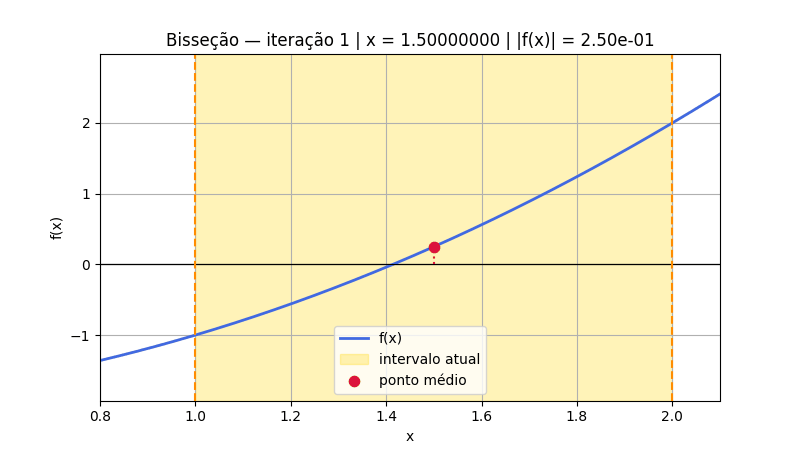

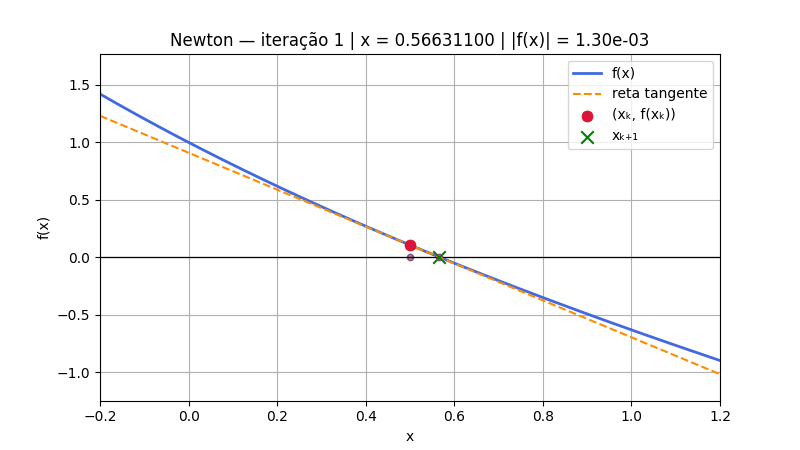

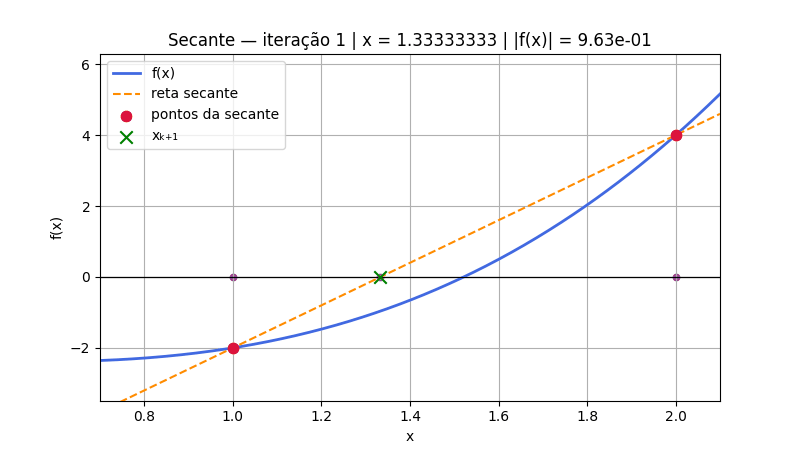

In [19]:
#Mostra o GIF da bisseção no notebook
display(Image(filename=gif_bissecao))

#Mostra o GIF de Newton no notebook
display(Image(filename=gif_newton))

#Mostra o GIF da secante no notebook
display(Image(filename=gif_secante))